In [1]:
import matplotlib.pyplot as plt
import numpy as np
import ecg_generator as eg
import ppg_generator as pg
import noise_generator as ng

# Biosignal generator exercise

Experiment with the biosignal generator and answer the questions. You can find help from the tutorial notebook in the github.

## Create signals with sinus rhythm and atrial fibrillation

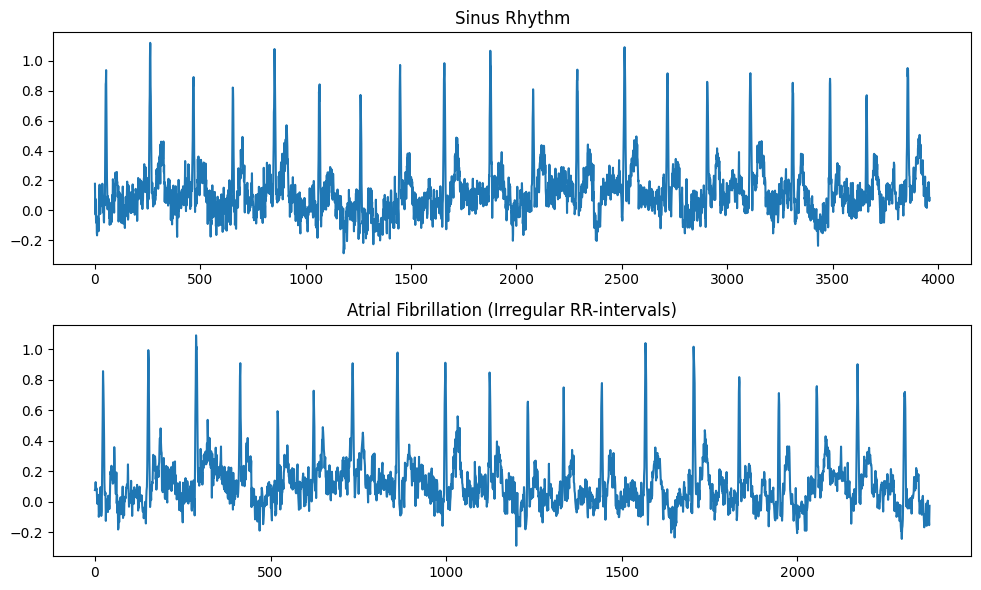

In [2]:
#Fill the code here
ecg_sr_gen = eg.ECGGenerator()
ecg_sr_gen.number_of_beats = 20
sig_sr, peaks_sr, labels_sr, beats_sr = ecg_sr_gen.generate()


ecg_af_gen = eg.ECGGenerator()
ecg_af_gen.number_of_beats = 20
ecg_af_gen.ecg_amplitude.p = 0.0
ecg_af_gen.beat_interval_generator.mu = 0.6 
ecg_af_gen.beat_interval_generator.std = 0.4 
sig_af, peaks_af, labels_af, beats_af = ecg_af_gen.generate()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
ax[0].plot(sig_sr)
ax[0].set_title("Sinus Rhythm")
ax[1].plot(sig_af)
ax[1].set_title("Atrial Fibrillation (Irregular RR-intervals)")
plt.tight_layout()
plt.show()

## Experiment with different noise levels

Try also creating longitudinal noise

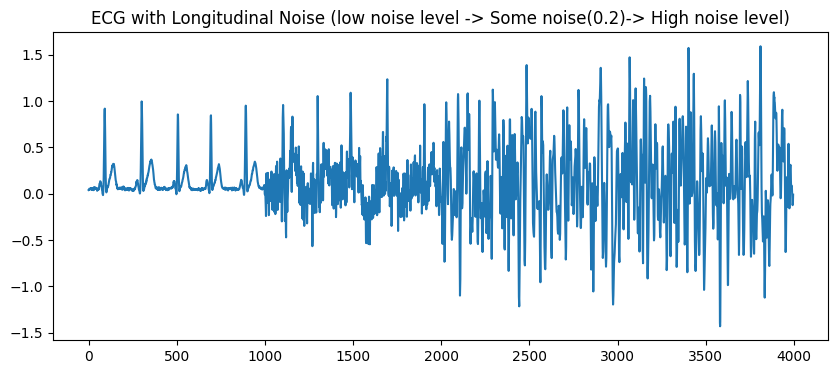

In [3]:
#Fill the code here
ecg_noise_gen = eg.ECGGenerator()

#Creating of Longitudinal noise
ecg_noise_gen.noise_generator.noise_list = [
    ng.NoiseType(name='model', duration=5, amplitude=0.01),      # Low white/pink noise
    ng.NoiseType(name='muscle_artifact', duration=5, amplitude=0.2), # Moderate muscle noise
    ng.NoiseType(name='walking', duration=10, amplitude=0.5)      # High intensity walking noise
]

sig_noisy, peaks_noisy, labels_noisy, beats_noisy = ecg_noise_gen.generate()

plt.figure(figsize=(10, 4))
plt.plot(sig_noisy)
plt.title("ECG with Longitudinal Noise (low noise level -> Some noise(0.2)-> High noise level)")
plt.show()

## Create ECG signal with ST elevation

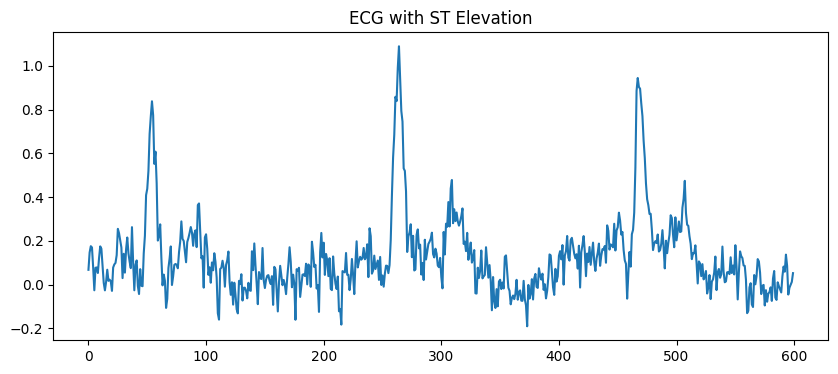

In [4]:
#Fill the code here
ecg_st_gen = eg.ECGGenerator()

# Normal S amplitude is approx -0.08. 
# Pulling the S-T segment up by making S amplitude positive and wider.
ecg_st_gen.ecg_amplitude.s = 0.2 
ecg_st_gen.ecg_width.s = 0.2
ecg_st_gen.ecg_distance.t = 0.2 # Moving T wave slightly closer to R

sig_st, peaks_st, labels_st, beats_st = ecg_st_gen.generate()

plt.figure(figsize=(10, 4))
plt.plot(sig_st[:600]) # Zoom in on a few beats
plt.title("ECG with ST Elevation")
plt.show()

## Answer questions below:

1. The class structure of the framework
2. How intervals are generated? 
3. How the change in the heart rate is generated?
4. How waveforms are generated?
5. How noise is generated?

Ans 1:

the main class of the framework is the signalGenerator. This takes the beat interval and wave parameters. ECGGenerator or PPGGenerator inherits from the SignalGenerator. parameters like amplitudes and distances that are needed here to get HR feautres like P,Q,R,S and T waves for ECG. There is also the BEATIntervalGenerator which generates the RR intervals. Lastly the NoiseGenerator add various types of noise and motion artifacts.  

Ans 2:

I used the BeatIntervalGenerator.generate() similar to the tutorial.
After going through the code and the paper, the mu is the mean beat interval. the beat interval is calculated using mu, respiratory modulation and a memory model that creates realistic long-term correlations in HRV. 

Ans 3:

The hear rate change is generated usinbg a sigmoid function. in the code the changed hr section is generated because of the changes in mu over a step_f in position step_i.

Ans 4:

In the paper it is said that each wave for the ecg is modeled as the derivative of a skewed gaussian function. the waves are summed and then numerically integgrated to get the final generated signal. 

Ans 5:

Noise is genarated from either real noisy signals like walking, or modeled mathmatically, using formulas that mimic electronic interference of white and pink noise. There is also the combine_signal_nmoise which adds the noise on top of the clear heart signal.